# Setup

In [1]:
import sys
from pathlib import Path

# Make the audit module importable from the notebook
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "research" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

RUN_ID = 26


In [2]:
from app.repository.backtest.database import SessionLocal
from app.repository.backtest.models import Run, RunConfig

db = SessionLocal()
recent = (
    db.query(Run.id, Run.status, Run.created_at, RunConfig.symbol, RunConfig.timeframe)
    .join(RunConfig, RunConfig.run_id == Run.id)
    .filter(Run.status == "completed")
    .order_by(Run.created_at.desc())
    .limit(30)
    .all()
)
db.close()

import pandas as pd
pd.DataFrame(recent, columns=["run_id", "status", "created_at", "symbol", "timeframe"])

,run_id,status,created_at,symbol,timeframe
0,37,completed,2026-04-30 14:58:20.522521,BATCH,15m
1,36,completed,2026-04-30 11:30:27.811958,BATCH,15m
2,35,completed,2026-04-30 10:05:51.880301,BATCH,15m
3,34,completed,2026-04-30 09:58:47.193511,BATCH,15m
4,33,completed,2026-04-30 08:53:20.177030,BATCH,15m
5,32,completed,2026-04-30 08:47:28.815985,BATCH,15m
6,31,completed,2026-04-30 08:35:31.586519,BNB/USDT,15m
7,30,completed,2026-04-29 15:26:29.562748,BNB/USDT,15m
8,29,completed,2026-04-29 14:42:57.944277,BATCH,15m
9,28,completed,2026-04-29 14:32:14.196502,PORTFOLIO,15m


# Trade log + sanity dashboard

In [3]:
from app.backtest.audit.trade_log import build_trade_log
from app.backtest.audit.sanity import run_sanity_audits

RUN_ID = 35
# Cell 2-revised: audit the whole batch at trade-level
tl = build_trade_log(RUN_ID)
print(f"Run {RUN_ID}: {len(tl.df)} trades across {tl.df['symbol'].nunique()} symbols")
print(f"Symbol breakdown:\n{tl.df['symbol'].value_counts().to_string()}\n")

sanity = run_sanity_audits(tl, single_direction=True)
print(f"Sanity verdict: {'PASS' if sanity['passed'] else 'FAIL'}\n")

CHECK_KEYS = ("pnl_concentration", "long_short_symmetry", "cost_sensitivity")
for name in CHECK_KEYS:
    result = sanity[name]
    icon = '✓' if result.get('passed', False) else ('—' if not result.get('applicable', True) else '✗')
    val = result.get('value', 'n/a')
    print(f"  {icon} {name}: value={val}")


tl.df.head()

Run 35: 4395 trades across 22 symbols
Symbol breakdown:
symbol
ETH/USDT      356
WIF/USDT      254
PYTH/USDT     251
AXS/USDT      251
API3/USDT     245
STX/USDT      236
FET/USDT      231
ARB/USDT      221
OP/USDT       220
MINA/USDT     216
ETHFI/USDT    209
HBAR/USDT     206
XLM/USDT      193
BERA/USDT     177
SOL/USDT      166
TON/USDT      164
TRX/USDT      158
BTC/USDT      155
XRP/USDT      154
ETC/USDT      153
HYPE/USDT      93
OG/USDT        86

Sanity verdict: FAIL

  ✓ pnl_concentration: value=0.0052476664950147954
  ✓ long_short_symmetry: value=n/a
  ✗ cost_sensitivity: value=n/a


,entry_time,exit_time,side,symbol,entry_price,exit_price,qty,ret_pct,ret_abs,holding_hours,exit_reason,run_id
0,2024-05-03 19:45:00,2024-05-03 21:15:00,BUY,ETH/USDT,3033.5200,3053.2908,2.9231,4.5109,40.0000,1.5000,SL,35
1,2024-05-03 19:45:00,2024-05-03 21:15:00,BUY,ETH/USDT,3033.5200,3053.2908,2.9231,4.5109,40.0000,1.5000,SL,35
2,2024-05-03 19:45:00,2024-05-03 21:15:00,BUY,ARB/USDT,1.0420,1.0491,8032.1285,4.7793,40.0000,1.5000,SL,35
3,2024-05-03 19:45:00,2024-05-03 22:00:00,BUY,STX/USDT,2.1291,2.1501,2389.4863,7.8625,40.0000,2.2500,SL,35
4,2024-05-05 13:15:00,2024-05-05 14:00:00,BUY,FET/USDT,2.1976,2.2203,2188.1838,8.3182,40.0000,0.7500,SL,35


# Equity curve

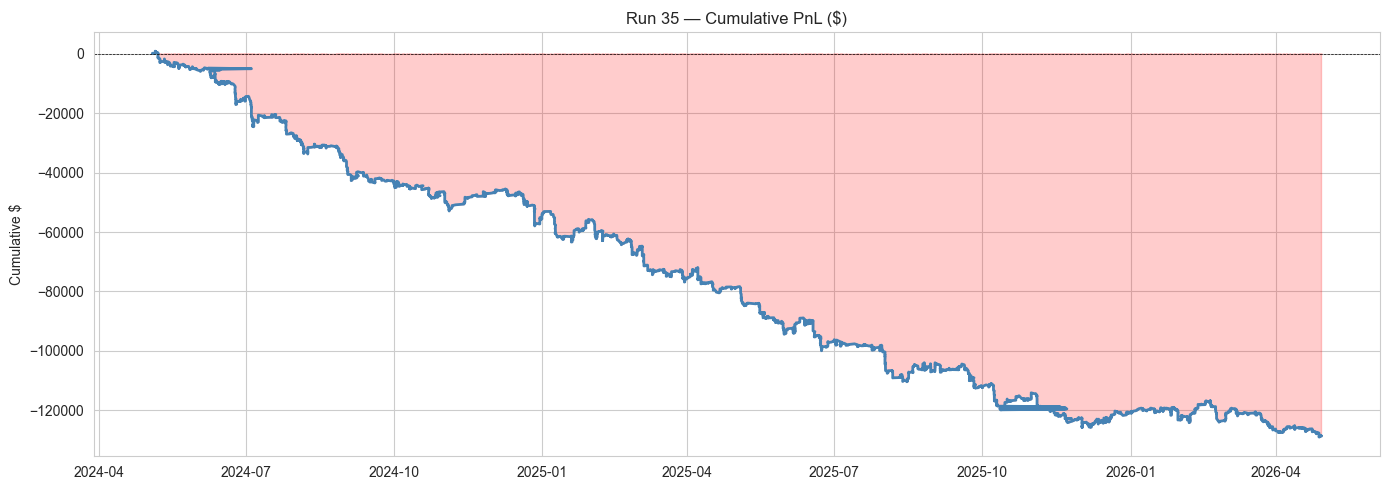

In [4]:
equity = tl.df.set_index('exit_time')['ret_abs'].cumsum()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(equity.index, equity.values, color='steelblue', linewidth=2)
ax.fill_between(equity.index, equity.values, 0,
                where=(equity.values >= 0), color='green', alpha=0.2)
ax.fill_between(equity.index, equity.values, 0,
                where=(equity.values < 0), color='red', alpha=0.2)
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title(f'Run {RUN_ID} — Cumulative PnL ($)')
ax.set_ylabel('Cumulative $')
plt.tight_layout()
plt.show()

# PnL concentration

Trades: 2926 wins / 1469 losses  (win rate 66.6%)
Avg win:  $  103.36
Avg loss: $ -293.35  (R:R = 1 : 2.84)
Total:    $-128492.41
Profit factor: 0.702


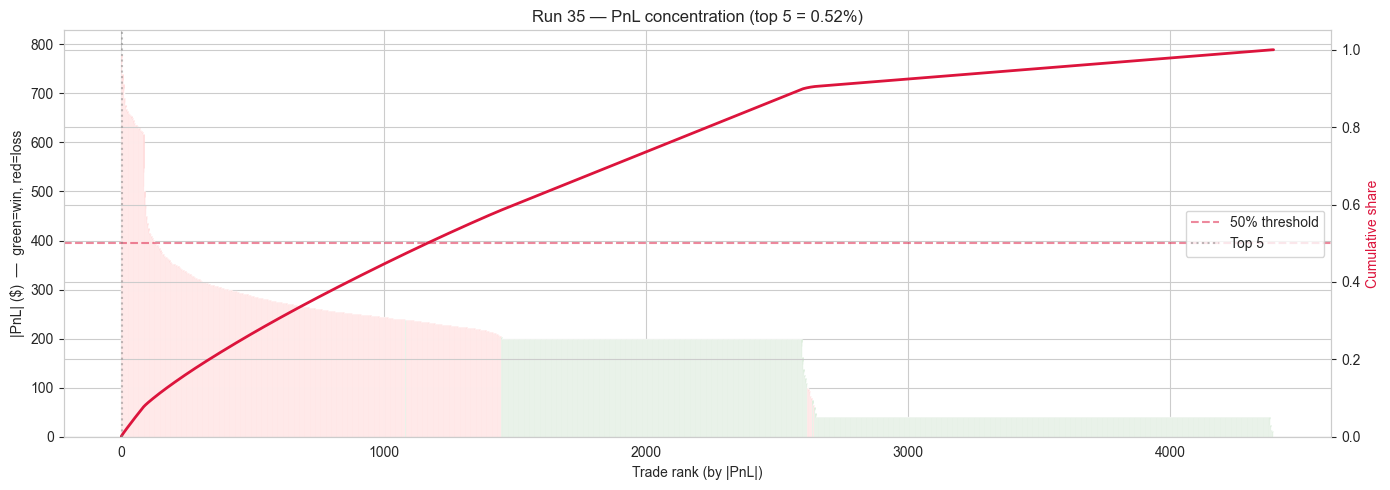

In [5]:
# Cell 4-revised: PnL concentration with win/loss coloring

# Sort trades by absolute PnL (descending) but keep the SIGN information
sorted_trades = (
    tl.df[['ret_abs']]
    .assign(abs_pnl=lambda d: d['ret_abs'].abs())
    .sort_values('abs_pnl', ascending=False)
    .reset_index(drop=True)
)
cum_share = sorted_trades['abs_pnl'].cumsum() / sorted_trades['abs_pnl'].sum()

# Color each bar by whether the trade was a win or loss
bar_colors = ['green' if r > 0 else 'red' for r in sorted_trades['ret_abs']]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(sorted_trades)), sorted_trades['abs_pnl'],
       color=bar_colors, alpha=0.6, width=1.0)
ax.set_xlabel('Trade rank (by |PnL|)')
ax.set_ylabel('|PnL| ($)  —  green=win, red=loss')

ax2 = ax.twinx()
ax2.plot(range(len(cum_share)), cum_share, color='crimson', linewidth=2)
ax2.axhline(0.5, color='crimson', linestyle='--', alpha=0.5, label='50% threshold')
ax2.axvline(4, color='gray', linestyle=':', alpha=0.5, label='Top 5')
ax2.set_ylabel('Cumulative share', color='crimson')
ax2.legend(loc='center right')
ax2.set_ylim(0, 1.05)

# Print summary stats so you don't have to eyeball
n_wins = (tl.df['ret_abs'] > 0).sum()
n_losses = (tl.df['ret_abs'] < 0).sum()
total_wins = tl.df.loc[tl.df['ret_abs'] > 0, 'ret_abs'].sum()
total_losses = tl.df.loc[tl.df['ret_abs'] < 0, 'ret_abs'].sum()
win_rate = n_wins / (n_wins + n_losses)
avg_win = total_wins / n_wins if n_wins else 0
avg_loss = total_losses / n_losses if n_losses else 0

print(f"Trades: {n_wins} wins / {n_losses} losses  (win rate {win_rate:.1%})")
print(f"Avg win:  ${avg_win:>8.2f}")
print(f"Avg loss: ${avg_loss:>8.2f}  (R:R = 1 : {abs(avg_loss)/avg_win:.2f})")
print(f"Total:    ${total_wins + total_losses:>8.2f}")
print(f"Profit factor: {total_wins / abs(total_losses):.3f}")

plt.title(f'Run {RUN_ID} — PnL concentration (top 5 = {sorted_trades["abs_pnl"].head(5).sum() / sorted_trades["abs_pnl"].sum():.2%})')
plt.tight_layout()
plt.show()

# Signal panel + RSI distribution

Using SYMBOL=ETH/USDT, TIMEFRAME=15m
Panel: 70054 bars, ETH/USDT 15m


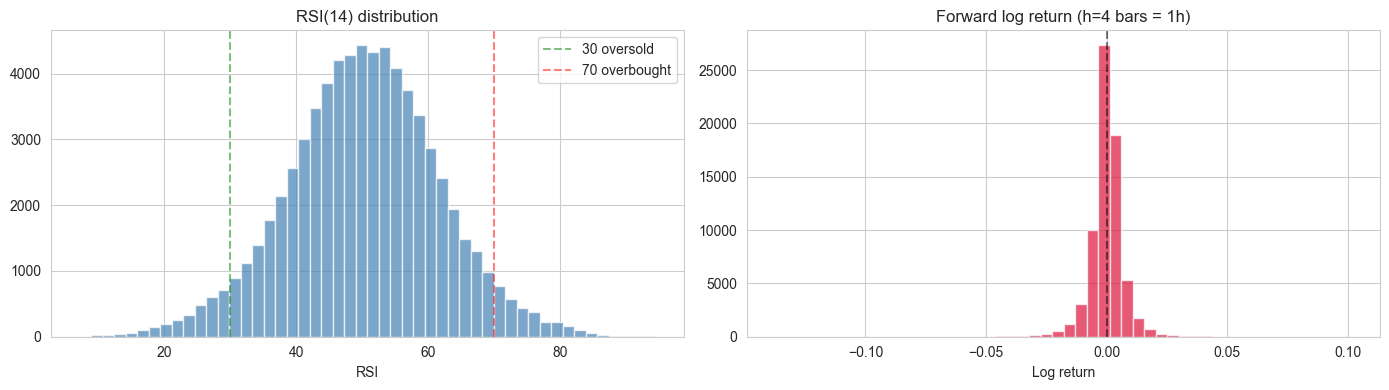

In [6]:
from app.backtest.audit.signal_panel import build_signal_panel

# Pick the most-traded symbol from this run; timeframe comes from RunConfig
SYMBOL = tl.df['symbol'].value_counts().idxmax()
db = SessionLocal()
TIMEFRAME = db.query(RunConfig.timeframe).filter(RunConfig.run_id == RUN_ID).scalar()
db.close()
print(f"Using SYMBOL={SYMBOL}, TIMEFRAME={TIMEFRAME}")

panel = build_signal_panel(SYMBOL, TIMEFRAME)
print(f"Panel: {len(panel.df)} bars, {panel.symbol} {panel.timeframe}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(panel.df['rsi_14'], bins=50, color='steelblue', alpha=0.7)
axes[0].axvline(30, color='green', linestyle='--', alpha=0.5, label='30 oversold')
axes[0].axvline(70, color='red', linestyle='--', alpha=0.5, label='70 overbought')
axes[0].set_title('RSI(14) distribution')
axes[0].set_xlabel('RSI')
axes[0].legend()

axes[1].hist(panel.df['fwd_logret_4'], bins=50, color='crimson', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Forward log return (h=4 bars = 1h)')
axes[1].set_xlabel('Log return')
plt.tight_layout()
plt.show()

# IC preview (decile chart, the moment of truth)

Spearman IC (h=4 bars): -0.0809, p-value: 3.9567e-50
Sample size: 33,771 bars


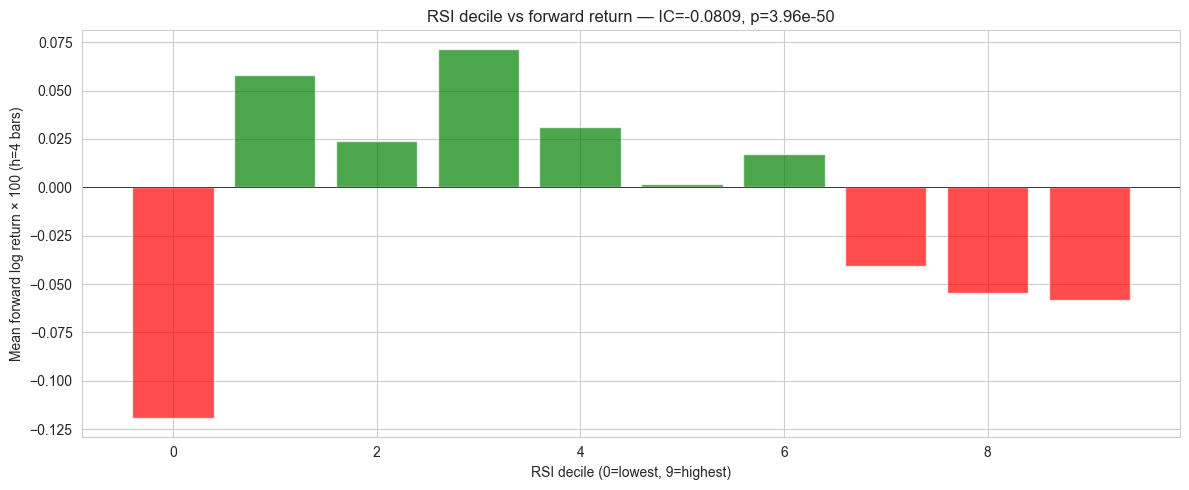

In [15]:
# Decile analysis — bin RSI, plot mean forward return per bin
# Monotonic = real signal. Zigzag = noise.

from scipy.stats import spearmanr
SYMBOL = "PYTH/USDT"
panel.df['rsi_decile'] = pd.qcut(panel.df['rsi_14'], 10, labels=False, duplicates='drop')
decile_summary = panel.df.groupby('rsi_decile').agg({
    'rsi_14': 'mean',
    'fwd_logret_4': ['mean', 'std', 'count']
})

# Spearman IC
ic, p_val = spearmanr(panel.df['rsi_14'], panel.df['fwd_logret_4'])
print(f"Spearman IC (h=4 bars): {ic:.4f}, p-value: {p_val:.4e}")
print(f"Sample size: {len(panel.df):,} bars")

fig, ax = plt.subplots(figsize=(12, 5))
deciles = decile_summary.index.values
mean_returns = decile_summary[('fwd_logret_4', 'mean')].values * 100  # to bps-ish
colors = ['red' if r < 0 else 'green' for r in mean_returns]
ax.bar(deciles, mean_returns, color=colors, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('RSI decile (0=lowest, 9=highest)')
ax.set_ylabel('Mean forward log return × 100 (h=4 bars)')
ax.set_title(f'RSI decile vs forward return — IC={ic:.4f}, p={p_val:.2e}')
plt.tight_layout()
plt.show()

In [16]:
# Cell 7: per-symbol IC, the actual test of your liquidity hypothesis
from app.backtest.audit.signal_panel import build_signal_panel
from scipy.stats import spearmanr

# Use the symbols actually traded in this run
symbols_in_run = tl.df['symbol'].value_counts()
symbols_to_test = symbols_in_run[symbols_in_run >= 20].index.tolist()  # min trade count filter

results = []
for sym in symbols_to_test:
    panel = build_signal_panel(sym, TIMEFRAME)
    ic, p = spearmanr(panel.df['rsi_14'], panel.df['fwd_logret_4'])
    n_trades = symbols_in_run[sym]
    n_bars = len(panel.df)
    results.append({
        'symbol': sym,
        'n_trades': n_trades,
        'n_bars': n_bars,
        'ic_h4': ic,
        'p_value': p,
    })

ic_df = pd.DataFrame(results).sort_values('ic_h4', key=abs, ascending=False)
print(ic_df.to_string(index=False))

    symbol  n_trades  n_bars   ic_h4  p_value
   OG/USDT        86   33771 -0.0809   0.0000
  TON/USDT       164   70054 -0.0406   0.0000
 HYPE/USDT        93   32037 -0.0400   0.0000
  BTC/USDT       155   69959 -0.0399   0.0000
  XRP/USDT       154   69958 -0.0395   0.0000
  XLM/USDT       193   70054 -0.0385   0.0000
 API3/USDT       245   70054 -0.0379   0.0000
ETHFI/USDT       209   70054 -0.0368   0.0000
 MINA/USDT       216   70054 -0.0339   0.0000
  ETC/USDT       153   70054 -0.0335   0.0000
  ETH/USDT       356   70054 -0.0324   0.0000
  FET/USDT       231   70054 -0.0322   0.0000
  STX/USDT       236   70054 -0.0267   0.0000
 HBAR/USDT       206   70054 -0.0250   0.0000
  TRX/USDT       158   70054  0.0249   0.0000
  SOL/USDT       166   69959 -0.0247   0.0000
   OP/USDT       220   70054 -0.0241   0.0000
 PYTH/USDT       251   70054 -0.0218   0.0000
  ARB/USDT       221   70054 -0.0211   0.0000
  WIF/USDT       254   70054 -0.0202   0.0000
 BERA/USDT       177   42867 -0.01

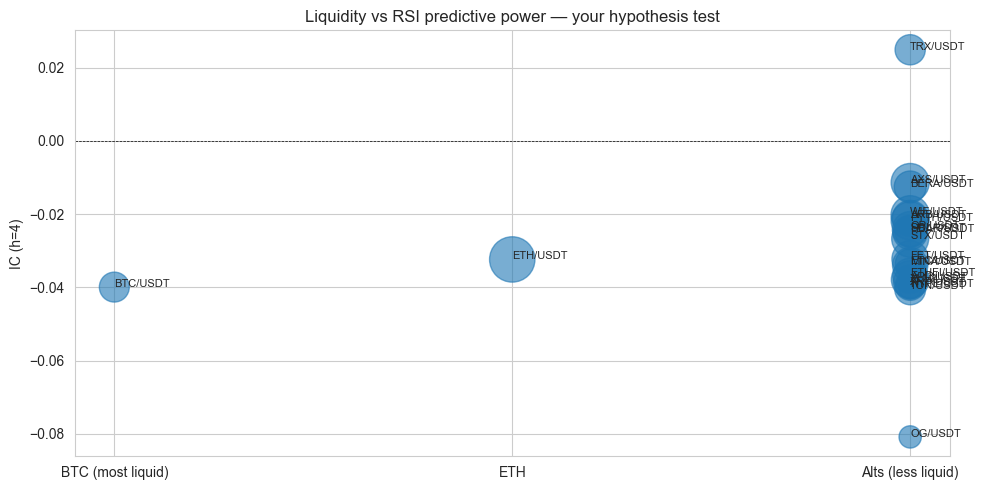

In [9]:
# Cell 8: liquidity vs IC scatter
# Approximate liquidity ordering — could be replaced with actual volume data
liquidity_rank = ic_df['symbol'].apply(lambda s: 1 if s == 'BTC/USDT' else (2 if s == 'ETH/USDT' else 3))
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(liquidity_rank, ic_df['ic_h4'], s=ic_df['n_trades']*3, alpha=0.6)
for _, row in ic_df.iterrows():
    ax.annotate(row['symbol'], (liquidity_rank[row.name], row['ic_h4']), fontsize=8)
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['BTC (most liquid)', 'ETH', 'Alts (less liquid)'])
ax.set_ylabel('IC (h=4)')
ax.set_title('Liquidity vs RSI predictive power — your hypothesis test')
plt.tight_layout()
plt.show()

In [10]:
# Cell 9: exit reason decomposition — the mechanism behind the win/loss split
print(tl.df['exit_reason'].value_counts())
print()

by_reason = tl.df.groupby('exit_reason').agg(
    count=('ret_pct', 'size'),
    mean_ret_pct=('ret_pct', 'mean'),
    sum_ret_abs=('ret_abs', 'sum'),
    mean_ret_abs=('ret_abs', 'mean'),
).sort_values('count', ascending=False)

print(by_reason.to_string())
print()
print(f"Total ret_abs: ${tl.df['ret_abs'].sum():.2f}")

exit_reason
SL                    1845
CLOSE_BY_CANDLE_SL    1352
TP1                   1198
Name: count, dtype: int64

                    count  mean_ret_pct  sum_ret_abs  mean_ret_abs
exit_reason                                                       
SL                   1845        2.2228    6750.1728        3.6586
CLOSE_BY_CANDLE_SL   1352      -25.3815 -368486.1294     -272.5489
TP1                  1198       19.5186  233243.5416      194.6941

Total ret_abs: $-128492.41


In [11]:
# Cell 10: how badly does CLOSE_BY_CANDLE_SL slip past the planned risk?
candle_sl = tl.df[tl.df['exit_reason'] == 'CLOSE_BY_CANDLE_SL'].copy()
candle_sl['planned_loss_pct'] = -2.0  # roughly the risk-per-trade as % of capital, expressed at trade level
candle_sl['actual_vs_planned'] = candle_sl['ret_pct'] / candle_sl['planned_loss_pct']

print("CLOSE_BY_CANDLE_SL trades — slippage analysis")
print(f"  Mean actual loss:    {candle_sl['ret_pct'].mean():.2f}%")
print(f"  Median actual loss:  {candle_sl['ret_pct'].median():.2f}%")
print(f"  Worst 10% loss:      {candle_sl['ret_pct'].quantile(0.10):.2f}%")
print(f"  Worst single loss:   {candle_sl['ret_pct'].min():.2f}%")
print()
print(f"Distribution of holding hours:")
print(f"  Mean holding hours:  {candle_sl['holding_hours'].mean():.2f}")
print(f"  Median:              {candle_sl['holding_hours'].median():.2f}")
print(f"  Max:                 {candle_sl['holding_hours'].max():.2f}")

CLOSE_BY_CANDLE_SL trades — slippage analysis
  Mean actual loss:    -25.38%
  Median actual loss:  -20.06%
  Worst 10% loss:      -40.98%
  Worst single loss:   -425.24%

Distribution of holding hours:
  Mean holding hours:  10.15
  Median:              3.50
  Max:                 1009.50


In [12]:
# Cell 11: which symbols are responsible for the catastrophic CANDLE_SL losses?
catastrophic = tl.df[
    (tl.df['exit_reason'] == 'CLOSE_BY_CANDLE_SL') &
    (tl.df['ret_pct'] < -30)  # the worst third of CANDLE_SL trades
].copy()

print(f"Catastrophic CANDLE_SL trades: {len(catastrophic)}")
print(f"Total contribution: ${catastrophic['ret_abs'].sum():,.2f}")
print()
print("By symbol:")
by_sym = catastrophic.groupby('symbol').agg(
    count=('ret_pct', 'size'),
    mean_loss_pct=('ret_pct', 'mean'),
    mean_holding=('holding_hours', 'mean'),
    sum_loss=('ret_abs', 'sum'),
).sort_values('sum_loss')
print(by_sym.to_string())

Catastrophic CANDLE_SL trades: 324
Total contribution: $-84,792.23

By symbol:
            count  mean_loss_pct  mean_holding   sum_loss
symbol                                                   
FET/USDT       30       -52.4964       16.7583 -7877.7376
WIF/USDT       30       -48.7814        6.9333 -7865.4570
API3/USDT      28       -39.6436        5.3125 -7671.1263
ETHFI/USDT     26       -61.4513       47.0192 -6286.5988
PYTH/USDT      19       -43.8667       11.1447 -5074.9095
OP/USDT        17       -41.9648        6.8971 -4855.8275
SOL/USDT       16       -38.7812        9.0000 -4269.3959
BERA/USDT      18       -40.3881        7.1389 -4257.4854
STX/USDT       15       -70.0794       72.2833 -4103.5604
ARB/USDT       17       -63.0038       71.2500 -4064.1105
MINA/USDT      14       -39.0158        5.1250 -3717.2764
XRP/USDT       14       -60.2517      121.5179 -3427.8465
ETH/USDT       12       -47.9678        9.2083 -3382.2750
XLM/USDT       12       -63.1362       81.0625 -331

In [13]:
# Cell 12: drill into the single worst trade
worst = tl.df[tl.df['ret_pct'] == tl.df['ret_pct'].min()].iloc[0]
print(f"Worst trade: {worst['symbol']}")
print(f"  Entry:  {worst['entry_time']} @ ${worst['entry_price']}")
print(f"  Exit:   {worst['exit_time']} @ ${worst['exit_price']}")
print(f"  Held:   {worst['holding_hours']:.1f} hours")
print(f"  Return: {worst['ret_pct']:.2f}% / ${worst['ret_abs']:.2f}")
print(f"  Reason: {worst['exit_reason']}")

Worst trade: ETHFI/USDT
  Entry:  2025-10-11 09:45:00 @ $1.1875
  Exit:   2025-11-22 11:15:00 @ $0.6844
  Held:   1009.5 hours
  Return: -425.24% / $-205.90
  Reason: CLOSE_BY_CANDLE_SL


In [14]:
# Cell 13: lock-profit conversion analysis
sl_grazes = tl.df[tl.df['exit_reason'] == 'SL']  # the lock-profit-stopped trades
print(f"Lock-profit graze trades: {len(sl_grazes)}")
print(f"  Mean ret_pct: {sl_grazes['ret_pct'].mean():.2f}%")
print(f"  Mean holding: {sl_grazes['holding_hours'].mean():.1f} hours")
print(f"  Median holding: {sl_grazes['holding_hours'].median():.1f} hours")

Lock-profit graze trades: 1845
  Mean ret_pct: 2.22%
  Mean holding: 4.9 hours
  Median holding: 2.2 hours


In [17]:
# Cell 14: IC at multiple horizons — is the negative direction stable across timescales?
from scipy.stats import spearmanr
horizons = [1, 4, 16, 96]
ic_results = []
for sym in symbols_to_test:
    panel = build_signal_panel(sym, TIMEFRAME)
    row = {'symbol': sym}
    for h in horizons:
        col = f'fwd_logret_{h}'
        ic, p = spearmanr(panel.df['rsi_14'], panel.df[col])
        row[f'ic_h{h}'] = ic
    ic_results.append(row)
ic_horizons = pd.DataFrame(ic_results)
print(ic_horizons.to_string(index=False))

    symbol   ic_h1   ic_h4  ic_h16  ic_h96
  ETH/USDT -0.0422 -0.0324 -0.0112 -0.0199
  WIF/USDT -0.0248 -0.0202 -0.0039 -0.0094
 PYTH/USDT -0.0218 -0.0218 -0.0172 -0.0074
  AXS/USDT -0.0202 -0.0114  0.0142 -0.0161
 API3/USDT -0.0341 -0.0379 -0.0200 -0.0219
  STX/USDT -0.0275 -0.0267  0.0049  0.0099
  FET/USDT -0.0335 -0.0322 -0.0117 -0.0055
  ARB/USDT -0.0281 -0.0211 -0.0082 -0.0105
   OP/USDT -0.0286 -0.0241 -0.0121 -0.0138
 MINA/USDT -0.0307 -0.0339 -0.0251 -0.0279
ETHFI/USDT -0.0363 -0.0368 -0.0316 -0.0048
 HBAR/USDT -0.0283 -0.0250 -0.0171 -0.0173
  XLM/USDT -0.0320 -0.0385 -0.0362 -0.0269
 BERA/USDT -0.0136 -0.0126  0.0192  0.0200
  SOL/USDT -0.0308 -0.0247 -0.0054 -0.0073
  TON/USDT -0.0328 -0.0406 -0.0399 -0.0288
  TRX/USDT  0.0162  0.0249  0.0459 -0.0030
  BTC/USDT -0.0414 -0.0399 -0.0282 -0.0183
  XRP/USDT -0.0444 -0.0395 -0.0243 -0.0090
  ETC/USDT -0.0378 -0.0335 -0.0062 -0.0197
 HYPE/USDT -0.0310 -0.0400 -0.0468 -0.0144
   OG/USDT -0.0617 -0.0809 -0.0917 -0.0119


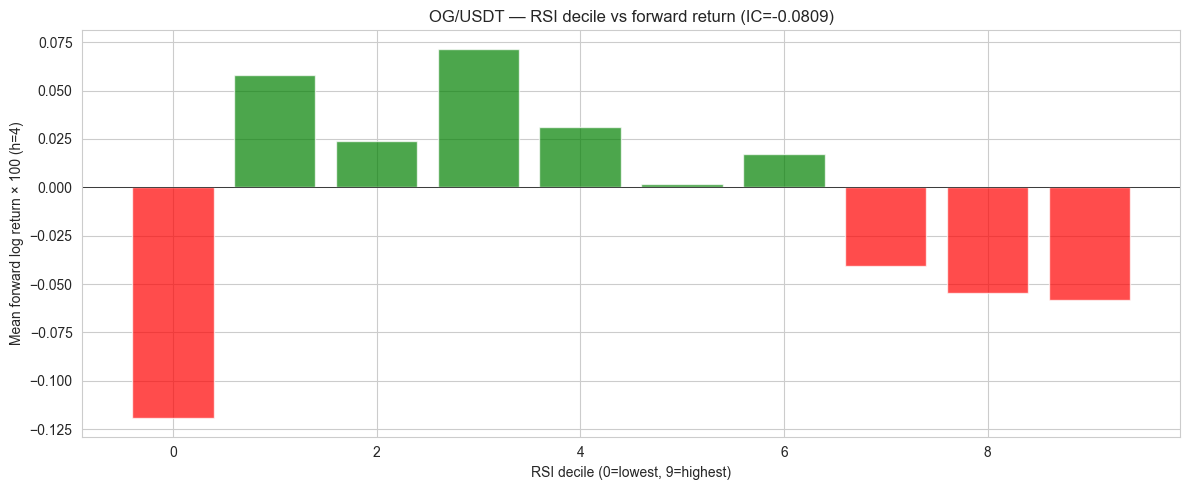

In [18]:
# Cell 15: decile chart for the strongest-IC symbol
SYMBOL = "OG/USDT"  # strongest IC magnitude
panel = build_signal_panel(SYMBOL, TIMEFRAME)
panel.df['rsi_decile'] = pd.qcut(panel.df['rsi_14'], 10, labels=False, duplicates='drop')
decile_mean = panel.df.groupby('rsi_decile')['fwd_logret_4'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['red' if r < 0 else 'green' for r in decile_mean]
ax.bar(decile_mean.index, decile_mean.values, color=colors, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('RSI decile (0=lowest, 9=highest)')
ax.set_ylabel('Mean forward log return × 100 (h=4)')
ax.set_title(f'{SYMBOL} — RSI decile vs forward return (IC=-0.0809)')
plt.tight_layout()
plt.show()